In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data = pd.read_csv("data.csv")

In [4]:
Data['property_type'] = Data['house_type'].apply(lambda x: (x.split()[2]))
Data['property_type'].value_counts()

,count
property_type,
Flat,5892
House,1555
Villa,238
BHK,6


In [10]:
from sklearn.preprocessing import LabelEncoder
categorical_col = ["locality","city","furnishing","property_type"]

for col in categorical_col:
  le = LabelEncoder()
  Data[col] = le.fit_transform(Data[col])

In [11]:
Data.sample(5)

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,property_type
5425,"3 BHK Flat for Rent in Hebbal, Bangalore",658,0,2200.0,3,4,2,1,86.0,190000.0,1
7229,"2 BHK Flat for Rent in Pirangut, Pune",1380,4,850.0,2,2,0,2,14.0,12000.0,1
2250,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",1389,1,476.0,1,2,0,0,95.0,45000.0,1
5254,"1 BHK Flat for Rent in Parshiwada, Mumbai",1334,1,2025.0,1,1,0,2,79.0,160000.0,1
2783,"3 BHK Flat for Rent in Lodha Park, Worli, Mumbai",1959,1,1092.0,3,3,0,2,223.0,240000.0,1


In [13]:
Data.drop(columns = ['house_type'],axis=1,inplace = True)

In [15]:
corr_matrix = Data.corr()
corr_matrix

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,property_type
locality,1.000000,0.094312,-0.011015,-0.018327,-0.024606,0.005253,0.016716,-0.027965,-0.015245,0.011970
city,0.094312,1.000000,-0.125663,-0.131277,-0.163518,0.004278,0.093305,-0.145132,-0.171352,-0.101172
area,-0.011015,-0.125663,1.000000,0.516329,0.535668,0.296145,-0.090037,0.022209,0.433513,0.140783
beds,-0.018327,-0.131277,0.516329,1.000000,0.850310,0.418587,-0.118684,0.111820,0.473695,0.018164
bathrooms,-0.024606,-0.163518,0.535668,0.850310,1.000000,0.442145,-0.130125,0.160051,0.532681,0.014835
balconies,0.005253,0.004278,0.296145,0.418587,0.442145,1.000000,-0.042480,-0.004592,0.179181,-0.074425
furnishing,0.016716,0.093305,-0.090037,-0.118684,-0.130125,-0.042480,1.000000,-0.086916,-0.124648,0.064327
area_rate,-0.027965,-0.145132,0.022209,0.111820,0.160051,-0.004592,-0.086916,1.000000,0.507104,-0.104656
rent,-0.015245,-0.171352,0.433513,0.473695,0.532681,0.179181,-0.124648,0.507104,1.000000,-0.031024
property_type,0.011970,-0.101172,0.140783,0.018164,0.014835,-0.074425,0.064327,-0.104656,-0.031024,1.000000


<Axes: >

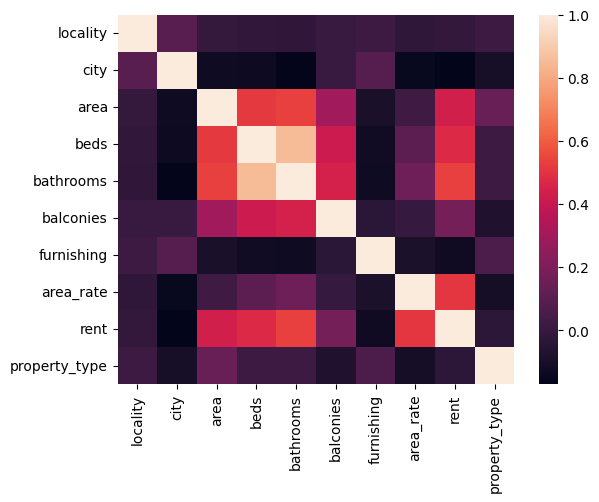

In [16]:
sns.heatmap(corr_matrix)

In [26]:
# Since Beds and Bathrooms are highly correlated we will drop either of them.

X = Data.drop(columns = ['rent','beds']) # remove the specific columns and its values for each row from the dataset.
y = Data['rent']  # show the specific columns and its values for each row of a dataset.


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)
x_train.shape,x_test.shape

((6152, 8), (1539, 8))

In [32]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [34]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train

array([[ 1.30913902, -0.00936119, -0.70510335, ..., -0.1853952 ,
        -0.05097863,  1.44273196],
       [-0.96601014, -0.00936119, -0.10333742, ..., -1.54806101,
         0.10734611, -0.5270166 ],
       [ 0.73335127, -1.33327029,  0.94154707, ..., -0.1853952 ,
         1.60423457, -0.5270166 ],
       ...,
       [ 0.01580423,  1.31454791, -0.61757376, ...,  1.17727061,
        -0.06537179, -0.5270166 ],
       [ 1.00811929,  0.65259336,  0.11548656, ..., -0.1853952 ,
        -0.38202127, -0.5270166 ],
       [ 0.91711332, -0.67131574,  0.33431054, ..., -0.1853952 ,
         2.13678142, -0.5270166 ]])

In [36]:
X_st = pd.DataFrame(x_train,columns=X.columns)
X_st.head(5)

,locality,city,area,bathrooms,balconies,furnishing,area_rate,property_type
0,1.309139,-0.009361,-0.705103,-0.129837,-0.651593,-0.185395,-0.050979,1.442732
1,-0.966010,-0.009361,-0.103337,-1.102741,-0.651593,-1.548061,0.107346,-0.527017
2,0.733351,-1.333270,0.941547,0.843068,1.765654,-0.185395,1.604235,-0.527017
3,0.441082,1.314548,-0.606633,-1.102741,-0.651593,1.177271,-0.468380,-0.527017
4,-0.068201,-0.671316,-0.869221,-1.102741,-0.651593,-1.548061,0.179312,-0.527017


In [37]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
from sklearn.metrics import r2_score

In [38]:
LR.fit(x_train,y_train)

LinearRegression()

In [39]:
pred = LR.predict(x_test)

In [40]:
acc = r2_score(y_test,pred)
acc

0.19267943903673257

In [ ]:
"""
Supervised Learning

Algorithms for Regression
1) Linear Regression
2) Decision Tree
3) Random Forest
4) XGBoost
5) KNN
6) SVM

Algorithms for Classification:
1) Logistic Regression
2) Naive Bayes
3) Decision Tree
4) Random Forest
5) XGBoost
6) KNN
7) SVM

"""

In [ ]:
"""
   Linear Regression            Simple LR                 Multiple LR

- Core Functionality             y = mx+c         y = m1x1+m2x2+m3x3+.....+c
- Parameters/weights               m,c
- Cost Function           (y-y_pred)^2 ---> x^2
- Evaluation metric       R2,MSE,MAE,RMSE,Adj_R2

"""